In [3]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.features import rasterize
from affine import Affine

In [ ]:
image_path = './image/Phase2_processed.tif'
mask_path = './mask/Phase2_mask.tif' # to be written
shape_path = './shape/phase_2_annotation.gpkg'
patched_data_output_dir = '../'

In [5]:
def write_data(filaneme:str, data:np.ndarray, transform:Affine, crs:rasterio.crs.CRS):
    with rasterio.open(filaneme, mode='w', **{
        "count" : data.shape[0],
        "height" : data.shape[1],
        "width" : data.shape[2],
        "transform" : transform,
        "nodata" : 0,
        "crs" : crs,
        "dtype" : data.dtype
    }) as dst:
        dst.write(data) 


import numpy as np
from scipy.ndimage import distance_transform_edt

def sample_n_valid_pixels(valid_mask, n, margin):
    """
    Returns N (y, x) pixels where a square patch of size 2*margin
    fits entirely inside valid_mask.
    """

    # distance to nearest False pixel
    dist = distance_transform_edt(valid_mask)

    # valid centers
    ys, xs = np.where(dist >= margin)

    if len(ys) == 0:
        raise ValueError("No valid pixels satisfy margin condition")

    # sample without replacement if possible
    replace = len(ys) < n
    idx = np.random.choice(len(ys), size=n, replace=replace)

    return  ys[idx], xs[idx]

def sample_valid_regular_points(valid_mask, x_diff, y_diff, margin):
    """
    Regular grid sampling inside valid mask.

    Parameters
    ----------
    valid_mask : (H, W) bool
    x_diff : int  → step in x direction
    y_diff : int  → step in y direction
    margin : int  → half patch size

    Returns
    -------
    ys, xs : arrays of valid centers
    """

    H, W = valid_mask.shape

    # distance map (same as your previous method)
    dist = distance_transform_edt(valid_mask)

    ys = []
    xs = []

    # grid sampling
    for y in range(margin, H - margin, y_diff):
        for x in range(margin, W - margin, x_diff):

            if dist[y, x] >= margin:
                ys.append(y)
                xs.append(x)

    if len(ys) == 0:
        raise ValueError("No valid grid points found")

    return np.array(ys), np.array(xs)

In [6]:

with rasterio.open(image_path, masked=True) as src:
    crs = src.crs
    height, width = src.height, src.width
    transform = src.transform

    # pr0jecting
    gdf = gpd.read_file(shape_path)
    if gdf.crs != crs:
        print('crs mismatch found projecting shapes tp image crs')
        gdf = gdf.to_crs(crs)

    # valid data mask (True where valid)
    valid_mask = np.any(src.read_masks(), axis=0)
    

    # final output mask (initialize as 0)
    final_mask = np.zeros((height, width), dtype=np.uint8)

    for cls_, group in (
        gdf.sort_values('render_order')
           .dropna(subset=['class', 'class_value'])
           .groupby('class')
    ):
        # (geometry, value)
        shapes = [
            (geom, val) for geom, val in zip(group.geometry, group.class_value)
        ]

        class_mask = rasterize(
            shapes=shapes,
            out_shape=(height, width),
            transform=transform,
            fill=0,
            dtype=np.int32
        )

        #  Apply valid pixel mask (ONLY keep where mask == 1)
        class_mask[~valid_mask] = 0

        # optional: merge into final mask
        final_mask = np.maximum(final_mask, class_mask)

    # # background
    # final_mask[(final_mask == 0) & valid_mask] = int(gdf['class_value'].max()) + 1
    
    # adding clannel dim
    final_mask = np.expand_dims(final_mask, 0)
    # writing data
    write_data(mask_path , final_mask, transform, crs)

## generate bbox [EXP]

In [7]:
box_size = 512
half = 512 // 2
margin = 50

In [8]:
# centers = sample_n_valid_pixels(valid_mask, 500, margin)
centers = sample_valid_regular_points(valid_mask, 256, 256, margin)
bboxs = [(x - half, y - half , x + half, y+ half) for x, y in zip(*centers)]

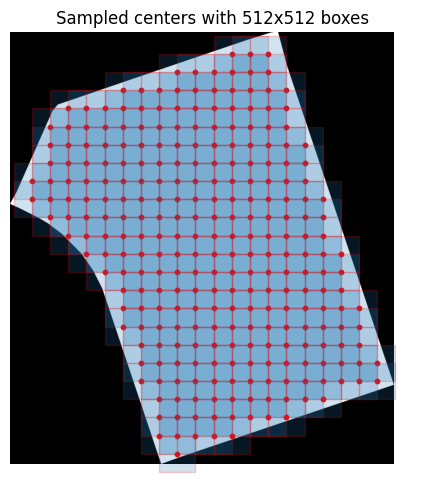

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches



fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(valid_mask, cmap="gray")

for y, x in zip(*centers):
    # draw center
    ax.scatter(x, y, c="red", s=10)

    # top-left corner
    x0 = x - half
    y0 = y - half

    # rectangle
    rect = patches.Rectangle(
        (x0, y0),
        box_size,
        box_size,
        linewidth=1,
        edgecolor="red",
        # facecolor="red",
        alpha = 0.2
    )
    ax.add_patch(rect)

ax.set_title("Sampled centers with 512x512 boxes")
ax.axis("off")
plt.show()

## generate patched training data

In [14]:
import rasterio
from rasterio.windows import from_bounds, Window
import numpy as np
import os
from sklearn.model_selection import train_test_split


def extract_patches_split(image_path, mask_path, bboxs, out_dir="./", train_ratio=0.7, seed=42):

    train_img_dir = os.path.join(out_dir, "training/images")
    train_mask_dir = os.path.join(out_dir, "training/masks")
    val_img_dir = os.path.join(out_dir, "validation/images")
    val_mask_dir = os.path.join(out_dir, "validation/masks")

    os.makedirs(train_img_dir, exist_ok=True)
    os.makedirs(train_mask_dir, exist_ok=True)
    os.makedirs(val_img_dir, exist_ok=True)
    os.makedirs(val_mask_dir, exist_ok=True)

    # 1. split bboxs
    train_boxes, val_boxes = train_test_split(
        bboxs,
        test_size=1 - train_ratio,
        random_state=seed
    )

    def process_boxes(boxes, img_dir, mask_dir):
        with rasterio.open(image_path) as src1, rasterio.open(mask_path) as src2:


            assert src1.crs == src2.crs, "CRS mismatch!"

            for i, (min_x, min_y, max_x, max_y) in enumerate(boxes):

                # pixel-space window
                window = Window.from_slices(
                    (int(min_y), int(max_y)),
                    (int(min_x), int(max_x))
                )
                # window = window.round_offsets().round_lengths()

                # read data
                img_patch = src1.read(window=window)
                mask_patch = src2.read(1, window=window)

                non_zero_pixel_per = (img_patch[0] > 0).sum() / (512 ** 2)
            
                if non_zero_pixel_per < 0.1:
                    print(f'non zero pixel percentage : {non_zero_pixel_per * 100}')
                    continue

                if img_patch.shape[1] < 512 or img_patch.shape[2] < 512:
                    print(f'invalid image shape : {img_patch.shape}')
                    continue

                if mask_patch.shape[0] < 512 or mask_patch.shape[1] < 512:
                    print(f'invalid mask shape : {mask_patch.shape}')
                    continue



                # save paths
                img_path = os.path.join(img_dir, f"{i}.tif")
                mask_path_out = os.path.join(mask_dir, f"{i}.tif")

                # update transform
                transform = src1.window_transform(window)

                # save image
                profile = src1.profile.copy()
                profile.update({
                    "height": img_patch.shape[1],
                    "width": img_patch.shape[2],
                    "transform": transform
                })

                with rasterio.open(img_path, "w", **profile) as dst:
                    dst.write(img_patch)

                # save mask
                mask_profile = src2.profile.copy()
                mask_profile.update({
                    "height": mask_patch.shape[0],
                    "width": mask_patch.shape[1],
                    "transform": transform,
                    "count": 1
                })

                with rasterio.open(mask_path_out, "w", **mask_profile) as dst:
                    dst.write(mask_patch, 1)

                

    # 2. process train
    process_boxes(train_boxes, train_img_dir, train_mask_dir)

    # 3. process val
    process_boxes(val_boxes, val_img_dir, val_mask_dir)

    print(f"Done → Train: {len(train_boxes)}, Val: {len(val_boxes)}")

In [15]:
extract_patches_split(image_path=image_path, mask_path=mask_path, bboxs=bboxs, out_dir=patched_data_output_dir)

non zero pixel percentage : 0.4119873046875
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
invalid image shape : (3, 512, 486)
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 5.975341796875
non zero pixel percentage : 0.72784423828125
non zero pixel percentage : 0.0
non zero pixel percentage : 8.182907104492188
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 5.3012847900390625
non zero pixel percentage : 0.0
non zero pixel percentage : 0.659942626953125
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 8.417892456054688
non zero pixel percentage : 0.0
non zero pixel percentage : 0.0
non zero pixel percentage : 8.631515502